In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import torch
import matplotlib.pyplot as plt

import kind
import ex_duffing
import util_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--file_dir', '../../data/dreamer',
        '--file_name', 'duffing',
        '--data_nsample', '8000',
        '--feature_ndim', '4',
        '--target_ndim', '2',
        '--data_train_size', '0.6',

        '--lookback_nsample', '384',
        '--forecast_nsample', '192',

        '--batch_size', '64',
        '--nepoch', '50',
        '--patience', '10',
        '--checkpoints', '../../models/dreamer',

        '--seg_nsample_stat', '192',
        '--seg_nsample_trans', '192',
        '--fun_stat', '{"sin": 4, "cos": 4}',
        '--fun_trans', '{"data": 12}',
    ]
)

In [3]:
model = kind.model(args)

dataset = ex_duffing.dataset(
    args.file_dir, args.file_name, args.file_ext,
    args.data_nsample,
    (args.data_train_size, args.data_test_size),
    args.batch_size, (args.lookback_nsample, args.forecast_nsample), load_normalized=True)

training = kind.training(model)

In [4]:
model.train()
training.fit(dataset)

>>> training nominal mean >>>
	epoch 1 losses: train=0.245910, valid=0.190187, test=0.189869
	validation loss decreased (inf -> 0.190187), saving model ...
	epoch 2 losses: train=0.056439, valid=0.002651, test=0.002677
	validation loss decreased (0.190187 -> 0.002651), saving model ...
	epoch 3 losses: train=0.001339, valid=0.000563, test=0.000560
	validation loss decreased (0.002651 -> 0.000563), saving model ...
	epoch 4 losses: train=0.000379, valid=0.000231, test=0.000231
	validation loss decreased (0.000563 -> 0.000231), saving model ...
	epoch 5 losses: train=0.000144, valid=0.000090, test=0.000090
	validation loss decreased (0.000231 -> 0.000090), saving model ...
	epoch 6 losses: train=0.000066, valid=0.000058, test=0.000058
	validation loss decreased (0.000090 -> 0.000058), saving model ...
	epoch 7 losses: train=0.000047, valid=0.000048, test=0.000048
	validation loss decreased (0.000058 -> 0.000048), saving model ...
	epoch 8 losses: train=0.000044, valid=0.000036, test=0.00

In [5]:
model.eval()
_, _, data_loader = dataset.load(data_type='nom')

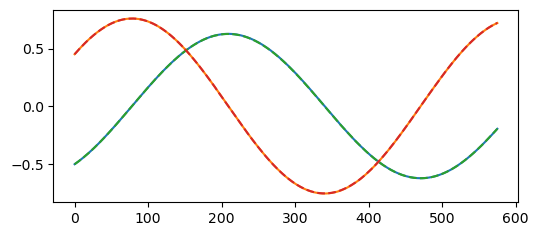

In [6]:
jdata = 2

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]

        plt.figure(figsize=(6,2.5))
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.show()

        break


In [7]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training nominal uncertainty >>>
	epoch 1 losses: train=0.041073, valid=0.035985, test=0.036015
	validation loss decreased (inf -> 0.035985), saving model ...
	epoch 2 losses: train=0.022691, valid=0.019502, test=0.019520
	validation loss decreased (0.035985 -> 0.019502), saving model ...
	epoch 3 losses: train=0.018093, valid=0.016397, test=0.016484
	validation loss decreased (0.019502 -> 0.016397), saving model ...
	epoch 4 losses: train=0.015191, valid=0.013596, test=0.013594
	validation loss decreased (0.016397 -> 0.013596), saving model ...
	epoch 5 losses: train=0.011414, valid=0.010162, test=0.010149
	validation loss decreased (0.013596 -> 0.010162), saving model ...
	epoch 6 losses: train=0.009740, valid=0.009766, test=0.009779
	validation loss decreased (0.010162 -> 0.009766), saving model ...
	epoch 7 losses: train=0.009333, valid=0.008990, test=0.009029
	validation loss decreased (0.009766 -> 0.008990), saving model ...
	epoch 8 losses: train=0.008213, valid=0.008897, te

In [8]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

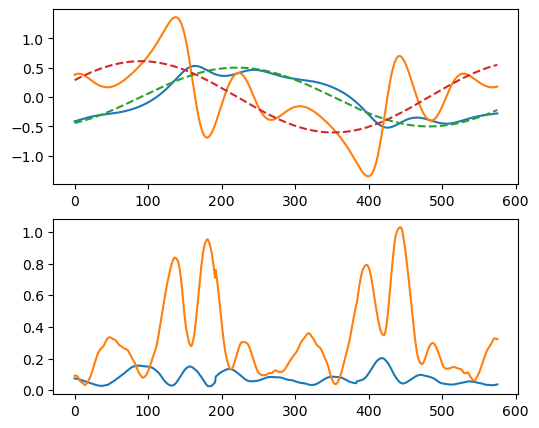

In [9]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]
        stat_u = model_output[2]

        plt.figure(figsize=(6,5))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(stat_u[0, :, :2])

        plt.show()

        break


In [10]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion mean >>>
	epoch 1 losses: train=0.254053, valid=0.233607, test=0.233317
	validation loss decreased (inf -> 0.233607), saving model ...
	epoch 2 losses: train=0.131160, valid=0.094719, test=0.094903
	validation loss decreased (0.233607 -> 0.094719), saving model ...
	epoch 3 losses: train=0.084436, valid=0.062872, test=0.063158
	validation loss decreased (0.094719 -> 0.062872), saving model ...
	epoch 4 losses: train=0.049009, valid=0.037362, test=0.037176
	validation loss decreased (0.062872 -> 0.037362), saving model ...
	epoch 5 losses: train=0.026684, valid=0.016577, test=0.016673
	validation loss decreased (0.037362 -> 0.016577), saving model ...
	epoch 6 losses: train=0.013010, valid=0.009165, test=0.009278
	validation loss decreased (0.016577 -> 0.009165), saving model ...
	epoch 7 losses: train=0.006898, valid=0.004101, test=0.004190
	validation loss decreased (0.009165 -> 0.004101), saving model ...
	epoch 8 losses: train=0.004055, valid=0.002394, test=0.

In [11]:
model.eval()
_, _, data_loader = dataset.load(data_type='exc')

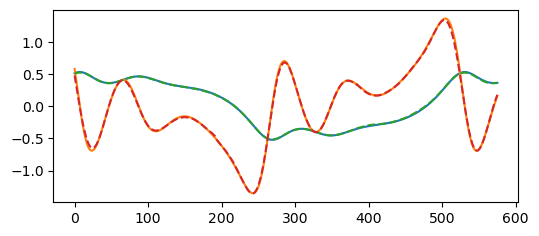

In [12]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[3]

        plt.figure(figsize=(6,2.5))
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.show()

        break

In [13]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion uncertainty >>>
	epoch 1 losses: train=0.049665, valid=0.026433, test=0.026526
	validation loss decreased (inf -> 0.026433), saving model ...
	epoch 2 losses: train=0.021981, valid=0.021095, test=0.021274
	validation loss decreased (0.026433 -> 0.021095), saving model ...
	epoch 3 losses: train=0.020511, valid=0.019621, test=0.019778
	validation loss decreased (0.021095 -> 0.019621), saving model ...
	epoch 4 losses: train=0.017728, valid=0.016520, test=0.016555
	validation loss decreased (0.019621 -> 0.016520), saving model ...
	epoch 5 losses: train=0.015670, valid=0.014342, test=0.014349
	validation loss decreased (0.016520 -> 0.014342), saving model ...
	epoch 6 losses: train=0.012519, valid=0.011775, test=0.011817
	validation loss decreased (0.014342 -> 0.011775), saving model ...
	epoch 7 losses: train=0.011301, valid=0.012225, test=0.012232
	early stopping counter: 1 out of 10
	epoch 8 losses: train=0.010452, valid=0.010541, test=0.010582
	validation loss 

In [14]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

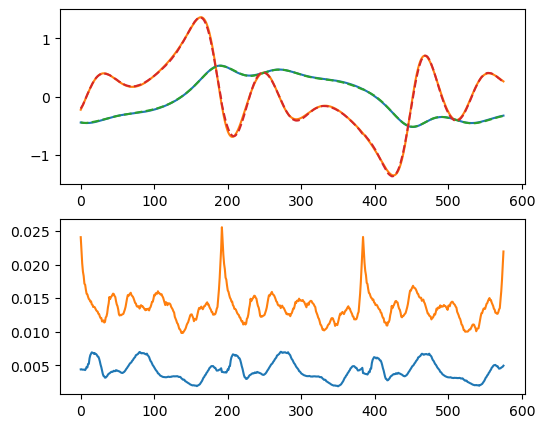

In [15]:
jdata = 3

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        exc = model_output[3]
        exc_u = model_output[4]

        plt.figure(figsize=(6,5))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(exc[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(exc_u[0, :, :2])

        plt.show()

        break

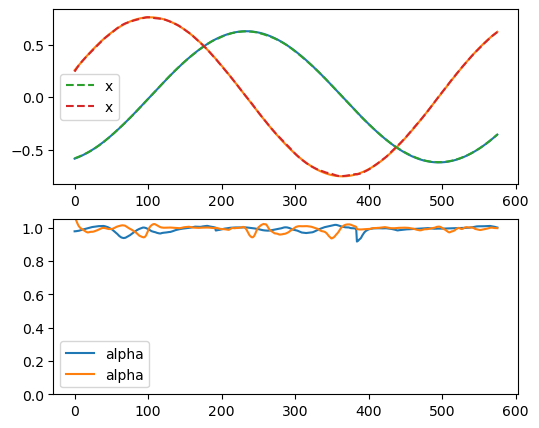

In [16]:
jdata = 10

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        pre = model_output[0]
        alpha = model_output[9]

        plt.figure(figsize=(6,5))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(pre[0, :, :2], linestyle='dashed', label='x')
        plt.legend()

        plt.subplot(2,1,2)
        plt.plot(alpha[0, :, :2], label='alpha')
        plt.ylim((0.0, 1.05))
        plt.legend()

        plt.show()

        break